# ZQE for Poisson GLLVM — encoder & link function comparison

## Findings

We compare two ZQE encoders against a VAE baseline and R's `gllvm` (VA) on simulated Poisson data
(`N=1000, p=20, q=1`). The decoder always uses a **log1p link** (`PoissonLog1pGLM`).

| Method | Procrustes ↓ |
|---|---|
| VAE (log1p encoder + log1p decoder) | 0.298 |
| ZQE — Gaussian MAP encoder, log1p decoder | **0.044** |
| ZQE — Poisson MAP encoder, log1p decoder | **0.043** |
| R `gllvm` VA | 0.045 |

**Key takeaways:**

1. **Encoder choice barely matters** once the decoder link is right. The cheap closed-form Gaussian MAP
   encoder (log1p-normalised least squares) is essentially as good as the exact Poisson MAP encoder
   (batched Newton GLM). The log1p compression makes counts approximately Gaussian, so the Gaussian
   MAP is already nearly exact.

2. **ZQE ≈ R gllvm (VA)** — we recover the same accuracy as the dedicated frequentist benchmark,
   without any explicit likelihood approximation, and in a form that scales to large $N$, $p$, $q$
   on GPU.

3. **The log1p link is doing the heavy lifting.** Swapping to an identity-link Poisson decoder
   roughly doubles the Procrustes error even with the exact encoder, because the poorly-scaled
   likelihood landscape makes optimisation harder.

## LR scheduling note

We use a **gradient-norm plateau detector**: fit a linear trend on a rolling window of per-epoch
mean gradient norms; if the slope is not significantly negative (one-sided t-test, $\alpha=0.1$),
halve the learning rate. This adapts naturally to the stochastic ZQE objective without needing a
hand-tuned cosine schedule.


In [1]:
%load_ext autoreload
%autoreload 2

import os, random, copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from gllvm.simulations import make_sparse, simulate
from gllvm.encoder import Encoder, MapEncoderGaussianLog1p, MapEncoderPoissonNewton
from gllvm.fitter import VAEFitter, ZQEPoissonFitter, ZQEFitter
from gllvm.glms import PoissonLog1pGLM

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEV = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEV)


device: cuda


## Simulation


In [12]:
torch.manual_seed(142543)

NL  = 2      # number of latent dims
ACT = NL     # active latents per response (= NL → dense, all latents identified)
NR  = 400000     # number of responses
NS  = 20    # number of observations
WZS = 1    # loading scale
RPL = NR   # None = dense loadings (each latent affects all responses)
             # set to NR//2 for row-sparse loadings (breaks dense decoders without L1)

g0m = make_sparse(n_latent=NL, poisson=NR, active_latent=ACT,
                  wz_scale=WZS, responses_per_latent=RPL).to(DEV)
y_all, z_all = simulate(g0m, n_samples=NS, device=DEV)

n_val  = int(0.15 * NS)
yt, yv = y_all[n_val:], y_all[:n_val]   # VAE uses train/val split
y_zqe  = y_all                           # ZQE uses all samples

print(f"g0m: p={g0m.p}  q={NL}  N={NS}")
print(f"y range: [{y_all.min().item():.0f}, {y_all.max().item():.0f}]")
print(f"true W shape: {g0m.wz.shape}")
W_nz = (g0m.wz.detach().cpu() != 0)
print(f"W non-zero per column: {W_nz.sum(0).tolist()}  (of {NR})")


# ── Procrustes helpers ────────────────────────────────────────────────────────
def _best_rotation(A, B):
    """Orthogonal Procrustes minimising ||A - B@R||, allowing reflections."""
    U, _, Vt = np.linalg.svd(A.T @ B)
    R1 = (U @ Vt).T
    D  = np.eye(U.shape[0]); D[-1, -1] = -1.0
    R2 = (U @ D @ Vt).T
    return R1 if np.linalg.norm(A - B @ R1) <= np.linalg.norm(A - B @ R2) else R2

def procr(g_true, g_est):
    a = g_true.wz.detach().cpu().numpy()
    b = g_est.wz.detach().cpu().numpy()
    R = _best_rotation(a, b)
    return float(np.linalg.norm(a - b @ R) / np.linalg.norm(a))

def _best_rotation_z(Z_true, Z_hat):
    U, _, Vt = np.linalg.svd(Z_true.T @ Z_hat)
    R1 = (U @ Vt).T
    D  = np.eye(U.shape[0]); D[-1, -1] = -1.0
    R2 = (U @ D @ Vt).T
    return R1 if np.linalg.norm(Z_true - Z_hat @ R1) <= np.linalg.norm(Z_true - Z_hat @ R2) else R2


g0m: p=400000  q=2  N=20
y range: [0, 22593]
true W shape: torch.Size([400000, 2])
W non-zero per column: [400000, 400000]  (of 400000)


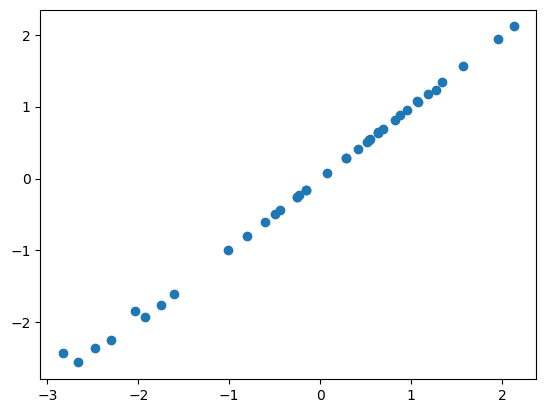

In [8]:
enc = MapEncoderPoissonNewton(g0m, lam=0.0, max_iter=100, tol=1e-8)
zhat = enc(y_zqe)
# TODO: WEIRD! TEST THAT for very large poisson, it is not perfect estimated at oracle!
plt.scatter(z_all.flatten().cpu().numpy(), zhat.flatten().cpu().numpy())

In [33]:
from gllvm.glm_fit import initial_gaussian_fit, poisson_newton_batch

B_true = g0m.wz.detach().cpu()
offset = g0m.bias.detach().cpu()

X = B_true
Y = y_all.T.cpu()
offset = offset.unsqueeze(1).expand_as(Y)


B0 = initial_gaussian_fit(X, Y, offset=offset)
B_hat, info = poisson_newton_batch(X, Y, B0, lam=1, offset=-offset, verbose=True)
z_hat = B_hat.T

Newton it=  1 rel_change=3.659e-01 halvings=4
Newton it=  2 rel_change=6.022e-01 halvings=1
Newton it=  3 rel_change=8.165e-02 halvings=0
Newton it=  4 rel_change=3.199e-02 halvings=0
Newton it=  5 rel_change=7.412e-03 halvings=0
Newton it=  6 rel_change=3.606e-04 halvings=0
Newton it=  7 rel_change=3.497e-07 halvings=1
Newton it=  6 rel_change=3.606e-04 halvings=0
Newton it=  7 rel_change=3.497e-07 halvings=1


In [ ]:
import numpy as np
from sklear.linear_model import PoissonRegressor

X_num =X.cpu().numpy()
Y_num = Y.cpu().numpy()
offset_num = offset.cpu().numpy()

offset = np.log(offset)

In [42]:
z_hat[15:16,:]

tensor([[2.4520, 2.0709]])

In [35]:
offset

tensor([[-0.1188, -0.1188, -0.1188,  ..., -0.1188, -0.1188, -0.1188],
        [ 1.0553,  1.0553,  1.0553,  ...,  1.0553,  1.0553,  1.0553],
        [-0.3165, -0.3165, -0.3165,  ..., -0.3165, -0.3165, -0.3165],
        ...,
        [ 0.9861,  0.9861,  0.9861,  ...,  0.9861,  0.9861,  0.9861],
        [ 1.5519,  1.5519,  1.5519,  ...,  1.5519,  1.5519,  1.5519],
        [-0.1731, -0.1731, -0.1731,  ..., -0.1731, -0.1731, -0.1731]])

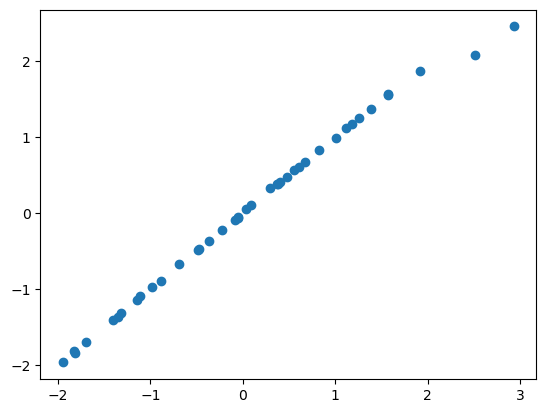

In [34]:
plt.scatter(z_all.flatten().cpu().numpy(), z_hat.flatten().cpu().numpy())

In [18]:
Z_hat = zhat         # (n, q)
B = Z_hat.T                 # (q, n)
W = g0m.wz                 # (p, q)
b = g0m.bias                 # (p,)
Y = y_zqe                 # (n, p)

eta = W @ B + b.unsqueeze(1)
mu = torch.exp(eta)

grad = W.T @ (mu - Y.T) + B   # lam=1
print(torch.linalg.norm(grad, dim=0))
print(torch.linalg.norm(grad, dim=0).max())
print(torch.linalg.norm(grad, dim=0).mean())

tensor([2.6191e-02, 2.7707e-02, 1.8033e-02, 5.5193e-02, 2.7671e-02, 2.1286e-01,
        2.7531e-01, 1.9227e-01, 2.7481e+00, 7.4453e-01, 2.7903e-01, 3.0216e-02,
        1.0867e+00, 2.3114e-01, 2.2917e-02, 1.4364e+02, 1.0428e-01, 5.7484e-01,
        2.7660e-01, 2.4234e-02], device='cuda:0',
       grad_fn=<LinalgVectorNormBackward0>)
tensor(143.6359, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(7.5297, device='cuda:0', grad_fn=<MeanBackward0>)


In [190]:
W = g0m.wz.detach().cpu()

print(W.shape)
print(torch.linalg.eigvalsh(W.T @ W))
print(torch.trace(W.T @ W))

torch.Size([4000, 2])
tensor([3908.3306, 4041.3167])
tensor(7949.6475)


## Setup


In [180]:
EPOCHS_ZQE = 3000
SMOOTH     = 5
VAE_HIDDEN = max(64, min(256, int(NR ** 0.5) * 4))


class Log1pEncoder(Encoder):
    """VAE encoder with log1p input normalisation."""
    def forward(self, y):
        return super().forward(torch.log1p(y.float()))


def fresh_decoder(glm_cls):
    """Completely fresh dense GLLVM — no mask, no knowledge of true sparse structure."""
    from gllvm.gllvm_module import GLLVM
    g = GLLVM(latent_dim=NL, output_dim=NR, bias=True).to(DEV)
    g.add_glm(glm_cls, idx=list(range(NR)), name="P")
    with torch.no_grad():
        nn.init.normal_(g.wz, std=WZS)
        nn.init.zeros_(g.bias)
    return g


def make_enc(enc_type, g):
    if enc_type == "gaussian_map":
        return MapEncoderGaussianLog1p(g)
    elif enc_type == "poisson_map":
        return MapEncoderPoissonNewton(g, lam=1.0, max_iter=30)
    else:
        raise ValueError(f"Unknown enc_type: {enc_type}")


# ── VAE baseline ──────────────────────────────────────────────────────────────
g_vae   = fresh_decoder(PoissonLog1pGLM).to(DEV)
enc_vae = Log1pEncoder(input_dim=NR, latent_dim=NL, hidden=VAE_HIDDEN).to(DEV)

WARMUP_EP = max(300, NR // 4)
fv = VAEFitter(g_vae, enc_vae, lr=1e-2, device=DEV)
fv.fit(yt, epochs=WARMUP_EP, batch_size=256, verbose=False)

for lr_stage, patience_stage in [(3e-3, 80), (1e-3, 100), (3e-4, 120), (1e-4, 150), (3e-5, 200)]:
    fitter = VAEFitter(g_vae, enc_vae, lr=lr_stage, device=DEV)
    best_ve = float("-inf"); no_imp = 0
    best_wz_v = best_b_v = best_enc_sd = None
    for ep in range(2000):
        fitter.fit(yt, epochs=1, batch_size=256, verbose=False)
        with torch.no_grad():
            _, ve = enc_vae.loss(yv.to(DEV), g_vae)
        if ve > best_ve + 0.05:
            best_ve, no_imp = ve, 0
            best_wz_v  = g_vae.wz.detach().clone()
            best_b_v   = g_vae.bias.detach().clone()
            best_enc_sd = copy.deepcopy(enc_vae.state_dict())
        else:
            no_imp += 1
            if no_imp >= patience_stage:
                break
    g_vae.wz.data.copy_(best_wz_v); g_vae.bias.data.copy_(best_b_v)
    enc_vae.load_state_dict(best_enc_sd)

err_vae = procr(g0m, g_vae)
print(f"VAE Procrustes = {err_vae:.4f}")


VAE Procrustes = 0.6377


## ZQE Training


In [181]:
ARMS = [
    # (label,                  colour,       glm_cls,         enc_type)
    ("Gaussian MAP (log1p)",   "tab:blue",   PoissonLog1pGLM, "gaussian_map"),
    ("Poisson MAP (log1p)",    "tab:orange", PoissonLog1pGLM, "poisson_map"),
]

results  = {}   # label -> (fitter, colour, enc_type, g, enc)

for label, colour, glm_cls, enc_type in ARMS:
    try:
        g   = fresh_decoder(glm_cls).to(DEV)
        enc = make_enc(enc_type, g)
        ft  = ZQEPoissonFitter(g, device=DEV, patience=100)
        print(f"\n[{label}]  Proc0={procr(g0m, g):.4f}")
        ft.fit(y_zqe, epochs=EPOCHS_ZQE)
        err = procr(g0m, ft.model)
        print(f"[{label}]  Procrustes = {err:.4f}")
        results[label] = (ft, colour, enc_type, g, enc)
    except Exception as _e:
        print(f"[{label}] FAILED: {_e}")
        import traceback; traceback.print_exc()


INFO:root:Initialized ZQE SGD Poisson Fitter with lr=1.0, min_lr=1e-08, patience=100, factor=0.5, threshold=0.001, n_mc=4, ema_decay=0.95, ema_start=20



[Gaussian MAP (log1p)]  Proc0=1.5338
  ep  100/3000  loss=+2.8815  gnorm=2.4812  lr=1.00e+00
  ep  100/3000  loss=+2.8815  gnorm=2.4812  lr=1.00e+00
    ↓ lr 1.00e+00→5.00e-01  gnorm=6.8073  ep=137
    ↓ lr 1.00e+00→5.00e-01  gnorm=6.8073  ep=137
  ep  200/3000  loss=-10.9373  gnorm=3.3987  lr=5.00e-01
  ep  200/3000  loss=-10.9373  gnorm=3.3987  lr=5.00e-01
    ↓ lr 5.00e-01→2.50e-01  gnorm=3.3760  ep=265
    ↓ lr 5.00e-01→2.50e-01  gnorm=3.3760  ep=265
  ep  300/3000  loss=+3.9899  gnorm=3.4263  lr=2.50e-01
  ep  300/3000  loss=+3.9899  gnorm=3.4263  lr=2.50e-01
  ep  400/3000  loss=+6.3084  gnorm=5.1183  lr=2.50e-01
    ↓ lr 2.50e-01→1.25e-01  gnorm=3.8761  ep=406
  ep  400/3000  loss=+6.3084  gnorm=5.1183  lr=2.50e-01
    ↓ lr 2.50e-01→1.25e-01  gnorm=3.8761  ep=406
  ep  500/3000  loss=+5.5379  gnorm=2.4975  lr=1.25e-01
    ↓ lr 1.25e-01→6.25e-02  gnorm=3.4175  ep=507
  ep  500/3000  loss=+5.5379  gnorm=2.4975  lr=1.25e-01
    ↓ lr 1.25e-01→6.25e-02  gnorm=3.4175  ep=507
  ep  60

INFO:root:Initialized ZQE SGD Poisson Fitter with lr=1.0, min_lr=1e-08, patience=100, factor=0.5, threshold=0.001, n_mc=4, ema_decay=0.95, ema_start=20


  ep 3000/3000  loss=+33.4275  gnorm=4.8192  lr=1.49e-08
[Gaussian MAP (log1p)]  Procrustes = 0.4815

[Poisson MAP (log1p)]  Proc0=1.3141
  ep  100/3000  loss=+8.5156  gnorm=3.0498  lr=1.00e+00
    ↓ lr 1.00e+00→5.00e-01  gnorm=5.0488  ep=109
  ep  100/3000  loss=+8.5156  gnorm=3.0498  lr=1.00e+00
    ↓ lr 1.00e+00→5.00e-01  gnorm=5.0488  ep=109
  ep  200/3000  loss=+48.1527  gnorm=5.0827  lr=5.00e-01
  ep  200/3000  loss=+48.1527  gnorm=5.0827  lr=5.00e-01
    ↓ lr 5.00e-01→2.50e-01  gnorm=5.0086  ep=256
    ↓ lr 5.00e-01→2.50e-01  gnorm=5.0086  ep=256
  ep  300/3000  loss=+8.4642  gnorm=2.7009  lr=2.50e-01
  ep  300/3000  loss=+8.4642  gnorm=2.7009  lr=2.50e-01
  ep  400/3000  loss=-11.1460  gnorm=3.2774  lr=2.50e-01
  ep  400/3000  loss=-11.1460  gnorm=3.2774  lr=2.50e-01
    ↓ lr 2.50e-01→1.25e-01  gnorm=3.4617  ep=486
    ↓ lr 2.50e-01→1.25e-01  gnorm=3.4617  ep=486
  ep  500/3000  loss=+14.0095  gnorm=2.3277  lr=1.25e-01
  ep  500/3000  loss=+14.0095  gnorm=2.3277  lr=1.25e-01
  

[skip] no data to plot for Deviance


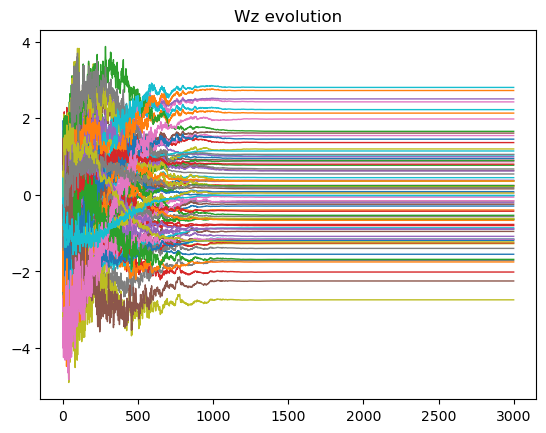

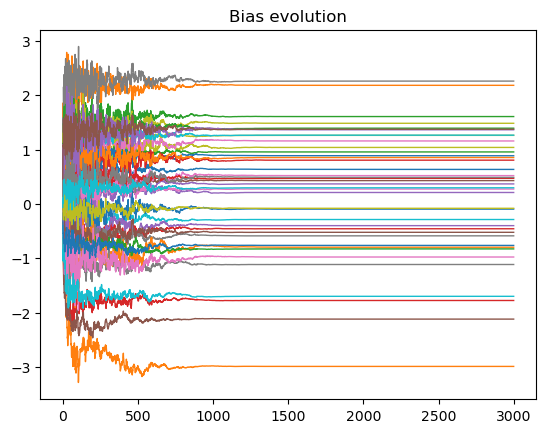

[skip] no data to plot for Latent evolution (fixed y-samples)


In [182]:
ft.history.plot()

## Results


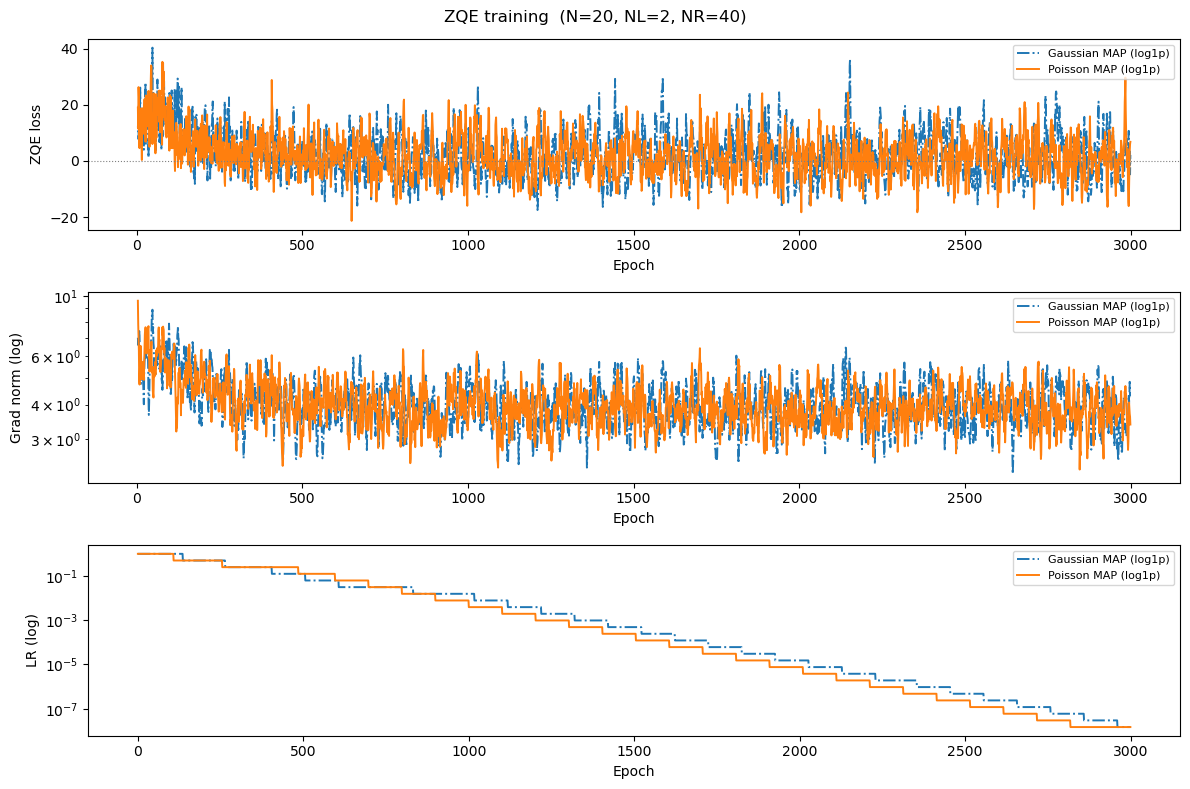


Method                                     Procrustes
──────────────────────────────────────────────────────
VAE                                            0.6377
Gaussian MAP (log1p)                           0.4815
Poisson MAP (log1p)                            0.4806


In [183]:
def smooth(x, w):
    return np.convolve(x, np.ones(w) / w, mode="valid")

fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
fig.suptitle(f"ZQE training  (N={NS}, NL={NL}, NR={NR})")

for label, (ft, col, enc_type, _g, _enc) in results.items():
    ls  = "-" if "Poisson" in label else "-."
    ep  = np.arange(len(ft.h_loss))
    eps = np.arange(SMOOTH - 1, len(ft.h_loss))   # x-axis for smoothed series
    ax0.plot(eps, smooth(ft.h_loss,  SMOOTH), color=col, lw=1.4, ls=ls, label=label)
    ax1.semilogy(eps, smooth(ft.h_gnorm, SMOOTH), color=col, lw=1.4, ls=ls, label=label)
    ax2.semilogy(ep,  ft.h_lr,       color=col, lw=1.4, ls=ls, label=label)

ax0.axhline(0, color="gray", ls=":", lw=0.8)
ax0.set_ylabel("ZQE loss");        ax0.legend(fontsize=8); ax0.set_xlabel("Epoch")
ax1.set_ylabel("Grad norm (log)"); ax1.legend(fontsize=8); ax1.set_xlabel("Epoch")
ax2.set_ylabel("LR (log)");        ax2.legend(fontsize=8); ax2.set_xlabel("Epoch")
plt.tight_layout(); plt.show()

# ── Final Procrustes table ────────────────────────────────────────────────────
print(f"\n{'Method':<40} {'Procrustes':>12}")
print("─" * 54)
print(f"{'VAE':<40} {err_vae:>12.4f}")
for label, (ft, col, enc_type, g, _enc) in results.items():
    print(f"{label:<40} {procr(g0m, ft.model):>12.4f}")


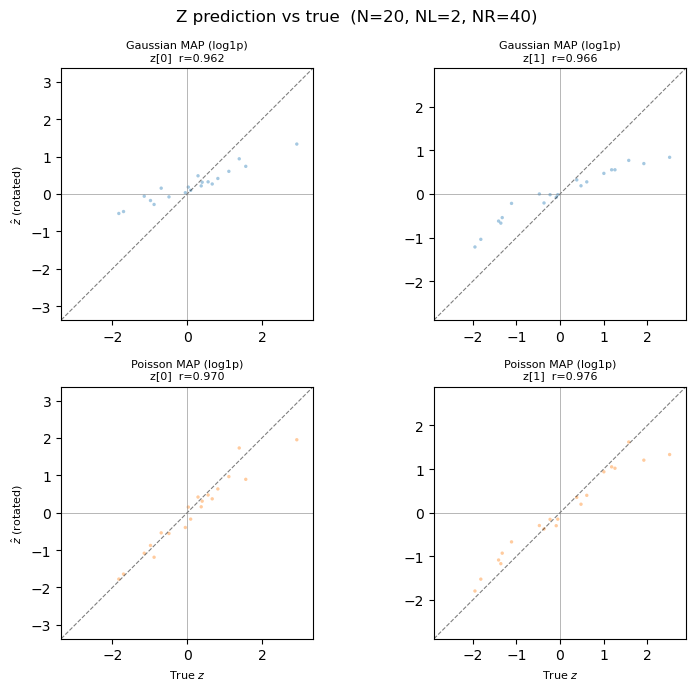

In [184]:
# ── Z prediction scatter ──────────────────────────────────────────────────────
z_true_np = z_all.cpu().numpy()
n_arms = len(results)

fig_z, axes_z = plt.subplots(n_arms, NL, figsize=(4 * NL, 3.5 * n_arms), squeeze=False)
fig_z.suptitle(f"Z prediction vs true  (N={NS}, NL={NL}, NR={NR})", fontsize=12)

for row, (label, (ft, col, enc_type, g_dec, enc)) in enumerate(results.items()):
    with torch.no_grad():
        z_hat, _, _ = enc.sample(y_zqe.to(DEV))
    z_hat_np  = z_hat.cpu().numpy()
    R         = _best_rotation_z(z_true_np, z_hat_np)
    z_hat_rot = z_hat_np @ R

    corr = [np.corrcoef(z_true_np[:, k], z_hat_rot[:, k])[0, 1] for k in range(NL)]

    for col_idx in range(NL):
        ax = axes_z[row, col_idx]
        ax.scatter(z_true_np[:, col_idx], z_hat_rot[:, col_idx],
                   s=6, alpha=0.4, color=col, edgecolors="none")
        lim = max(np.abs(z_true_np[:, col_idx]).max(),
                  np.abs(z_hat_rot[:, col_idx]).max()) * 1.15
        ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.8, alpha=0.5)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.set_aspect("equal")
        ax.axhline(0, color="gray", lw=0.4); ax.axvline(0, color="gray", lw=0.4)
        ax.set_title(f"{label}\nz[{col_idx}]  r={corr[col_idx]:.3f}", fontsize=8)
        if row == n_arms - 1: ax.set_xlabel("True $z$", fontsize=8)
        if col_idx == 0:      ax.set_ylabel(r"$\hat{z}$ (rotated)", fontsize=8)

plt.tight_layout(); plt.show()


## R gllvm Benchmark (VA)


In [185]:
import subprocess, os, textwrap
import pandas as pd

RSCRIPT    = "/mnt/c/Program Files/R/R-4.5.1/bin/Rscript.exe"
WIN_TMPDIR = "/mnt/c/Users/willwhite/AppData/Local/Temp/r_gllvm_bench"
os.makedirs(WIN_TMPDIR, exist_ok=True)

def wsl2r(path):
    """Convert /mnt/c/... WSL path to C:/... forward-slash path for R."""
    return path.replace("/mnt/c/", "C:/")

def run_r_gllvm(Y_np, W_true_np, n_latent, method="VA", family="poisson", seed=42):
    y_path = os.path.join(WIN_TMPDIR, "Y.csv")
    w_path = os.path.join(WIN_TMPDIR, f"W_hat_{method}.csv")
    r_path = os.path.join(WIN_TMPDIR, f"run_{method}.R")

    if os.path.exists(w_path):
        os.remove(w_path)

    pd.DataFrame(Y_np).to_csv(y_path, index=False, header=False)

    r_code = textwrap.dedent(f"""
        set.seed({seed})
        Y <- as.matrix(read.csv("{wsl2r(y_path)}", header=FALSE))
        suppressPackageStartupMessages(library(gllvm))
        fit <- gllvm(Y, num.lv={n_latent}, family="{family}",
                     method="{method}", starting.val="res",
                     control=list(maxit=2000), trace=FALSE)
        W_full <- sweep(fit$params$theta, 2, fit$params$sigma.lv, "*")
        write.csv(W_full, "{wsl2r(w_path)}", row.names=FALSE)
        cat("converged\\n")
    """)

    with open(r_path, "w") as f:
        f.write(r_code)

    result = subprocess.run(
        [RSCRIPT, "--vanilla", wsl2r(r_path)],
        capture_output=True, text=True, timeout=600
    )
    if result.returncode != 0 or not os.path.exists(w_path):
        print("R stderr:", result.stderr[-1500:])
        return None

    W_hat = pd.read_csv(w_path).values
    U, _, Vt = np.linalg.svd(W_true_np.T @ W_hat)
    R = (U @ Vt).T
    err = float(np.linalg.norm(W_true_np - W_hat @ R) / np.linalg.norm(W_true_np))
    return err, W_hat

# ── run VA only ───────────────────────────────────────────────────────────────
Y_int    = y_all.cpu().numpy().astype(int)
W_true_r = g0m.wz.detach().cpu().numpy()

r_results = {}
print("Fitting R gllvm (VA) ...")
out = run_r_gllvm(Y_int, W_true_r, n_latent=NL, method="VA")
if out is not None:
    err, W_hat = out
    r_results["R gllvm (VA)"] = (err, W_hat)
    print(f"  R gllvm VA  Procrustes = {err:.4f}")
else:
    print("  R gllvm VA failed")
    r_results["R gllvm (VA)"] = (float("nan"), None)


Fitting R gllvm (VA) ...
  R gllvm VA  Procrustes = 0.4185
  R gllvm VA  Procrustes = 0.4185


## Summary


Method                                      Procrustes
------------------------------------------------------
VAE baseline                                    0.6377
Gaussian MAP (log1p)                            0.4815
Poisson MAP (log1p)                             0.4806
R gllvm (VA)                                    0.4185


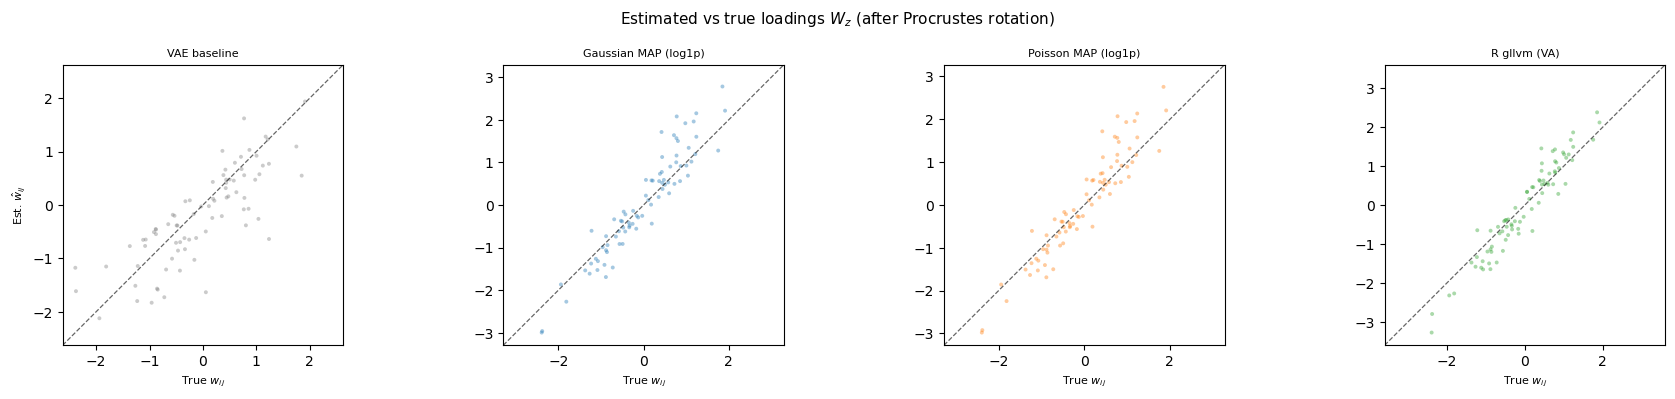

In [186]:
W_true_np = g0m.wz.detach().cpu().numpy()

def _aligned_w(W_t, W_h):
    return W_h @ _best_rotation(W_t, W_h)

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'Method':<40}  {'Procrustes':>12}")
print("-" * 54)
print(f"{'VAE baseline':<40}  {err_vae:>12.4f}")
for label, (ft, col, enc_type, g_dec, _enc) in results.items():
    print(f"{label:<40}  {procr(g0m, ft.model):>12.4f}")
for rname, (rerr, _) in r_results.items():
    print(f"{rname:<40}  {rerr:>12.4f}")

# ── Rotated loadings scatter ───────────────────────────────────────────────────
plot_methods = [("VAE baseline", "tab:gray", g_vae.wz.detach().cpu().numpy())]
for label, (ft, col, enc_type, g_dec, _enc) in results.items():
    plot_methods.append((label, col, g_dec.wz.detach().cpu().numpy()))
for rname, (rerr, W_hat) in r_results.items():
    if W_hat is not None:
        plot_methods.append((rname, "tab:green", W_hat))

ncols = len(plot_methods)
fig_w, axes_w = plt.subplots(1, ncols, figsize=(4.5 * ncols, 4), squeeze=False)
fig_w.suptitle("Estimated vs true loadings $W_z$ (after Procrustes rotation)", fontsize=11)

for ax, (label, col, W_hat) in zip(axes_w[0], plot_methods):
    W_rot = _aligned_w(W_true_np, W_hat)
    ax.scatter(W_true_np.ravel(), W_rot.ravel(),
               s=8, alpha=0.4, color=col, edgecolors="none")
    lim = max(np.abs(W_true_np).max(), np.abs(W_rot).max()) * 1.1
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.9, alpha=0.6)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_title(label, fontsize=8)
    ax.set_xlabel("True $w_{ij}$", fontsize=8)
axes_w[0, 0].set_ylabel(r"Est. $\hat{w}_{ij}$", fontsize=8)

plt.tight_layout(); plt.show()
